In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from google.colab import drive

from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_recall_fscore_support
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/DL_Project_Dataset"

assert os.path.isdir(DATA_ROOT), f"DATA_ROOT not found: {DATA_ROOT}"
print("DATA_ROOT:", DATA_ROOT)

Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/DL_Project_Dataset


In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [4]:
from collections import Counter

tmp_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

full_dataset_tmp = datasets.ImageFolder(root=DATA_ROOT, transform=tmp_transform)

classes = full_dataset_tmp.classes
NUM_CLASSES = len(classes)
print("Num classes:", NUM_CLASSES)
print("Classes:", classes)

total_images = len(full_dataset_tmp.samples)
print("Total images:", total_images)

class_counts = Counter([y for _, y in full_dataset_tmp.samples])
df_class = pd.DataFrame([
    {"class_idx": i, "class_name": name, "n_images": class_counts.get(i, 0)}
    for i, name in enumerate(classes)
]).sort_values("n_images", ascending=False).reset_index(drop=True)
df_class["pct"] = (df_class["n_images"] / total_images * 100).round(2)
df_class

Num classes: 8
Classes: ['Ford_F-150_(thirteenth_generation)', 'Ford_Mustang_VI', 'Renault_Kangoo_I', 'Renault_Twizy_Z.E', 'Toyota_Land_Cruiser_(J40)', 'Toyota_Supra_(A80)', 'Volkswagen_Passat_B6', 'Volkswagen_Type_1']
Total images: 1452


,class_idx,class_name,n_images,pct
0,3,Renault_Twizy_Z.E,245,16.87
1,0,Ford_F-150_(thirteenth_generation),235,16.18
2,1,Ford_Mustang_VI,194,13.36
3,7,Volkswagen_Type_1,194,13.36
4,4,Toyota_Land_Cruiser_(J40),186,12.81
5,5,Toyota_Supra_(A80),157,10.81
6,2,Renault_Kangoo_I,133,9.16
7,6,Volkswagen_Passat_B6,108,7.44


In [5]:
ext_counts = Counter([os.path.splitext(p)[1].lower() for p, _ in full_dataset_tmp.samples])
df_ext = pd.DataFrame([
    {"format": (ext if ext else "(no_ext)"), "n_images": n, "pct": round(n / total_images * 100, 2)}
    for ext, n in ext_counts.items()
]).sort_values("n_images", ascending=False).reset_index(drop=True)
df_ext

,format,n_images,pct
0,.jpg,1452,100.0


In [6]:
indices = np.arange(total_images)
labels  = np.array([y for _, y in full_dataset_tmp.samples])

train_idx, val_idx, y_train, y_val = train_test_split(
    indices, labels, test_size=0.20, random_state=SEED, stratify=labels
)

print("Train size:", len(train_idx))
print("Val size  :", len(val_idx))

Train size: 1161
Val size  : 291


In [7]:
from collections import Counter

def split_distribution(name, idxs, labels_arr, classes_list, all_indices):
    mask = np.isin(all_indices, idxs)
    c = Counter(labels_arr[mask])
    df = pd.DataFrame([
        {"split": name, "class_idx": i, "class_name": classes_list[i], "n": c.get(i, 0)}
        for i in range(len(classes_list))
    ])
    df["pct"] = (df["n"] / len(idxs) * 100).round(2)
    return df

df_train = split_distribution("train", train_idx, labels, classes, indices)
df_val   = split_distribution("val",   val_idx,   labels, classes, indices)

df_splits = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)
df_splits

,split,class_idx,class_name,n,pct
0,train,0,Ford_F-150_(thirteenth_generation),188,16.19
1,train,1,Ford_Mustang_VI,155,13.35
2,train,2,Renault_Kangoo_I,106,9.13
3,train,3,Renault_Twizy_Z.E,196,16.88
4,train,4,Toyota_Land_Cruiser_(J40),149,12.83
5,train,5,Toyota_Supra_(A80),126,10.85
6,train,6,Volkswagen_Passat_B6,86,7.41
7,train,7,Volkswagen_Type_1,155,13.35
8,val,0,Ford_F-150_(thirteenth_generation),47,16.15
9,val,1,Ford_Mustang_VI,39,13.40


In [8]:
train_dataset = datasets.ImageFolder(root=DATA_ROOT, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=DATA_ROOT, transform=val_transform)

train_ds = Subset(train_dataset, train_idx)
val_ds   = Subset(val_dataset,   val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))

Train batches: 37
Val batches  : 10


In [9]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.relu  = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.relu(out + identity)
        return out


class CustomResNet(nn.Module):
    def __init__(self, num_classes=8):
        super().__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(BasicBlock, 64,  2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(p=0.3)
        self.fc      = nn.Linear(512 * BasicBlock.expansion, num_classes)

        self._init_weights()

    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1.)
                nn.init.constant_(m.bias, 0.)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0.)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

model = CustomResNet(num_classes=NUM_CLASSES).to(device)
print(model.__class__.__name__, "Num classes:", NUM_CLASSES)

CustomResNet Num classes: 8


In [15]:
def accuracy_from_logits(logits, y):
    pred = torch.argmax(logits, dim=1)
    return (pred == y).float().mean().item()

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total

@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    all_true, all_pred = [], []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        pred = logits.argmax(1)
        total_loss += loss.item() * x.size(0)
        total_correct += (pred == y).sum().item()
        total += x.size(0)

        all_true.extend(y.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())

    acc = total_correct / total
    return total_loss / total, acc

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, weight_decay=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    best_val_acc = -1.0
    best_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = eval_epoch(model, val_loader, criterion)

        scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} || "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
        )

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_wts = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    print("Best val acc:", best_val_acc)
    model.load_state_dict({k: v.to(device) for k, v in best_wts.items()})
    return model, history

In [26]:
EPOCHS = 30
LR = 3e-4

model, history = train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90594944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Epoch 01/30 | train loss 1.4143 acc 0.4892 || val loss 1.7281 acc 0.4570 | 


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90594944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Epoch 02/30 | train loss 1.1256 acc 0.6253 || val loss 2.0630 acc 0.4021 | 


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90594944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


...

Epoch 28/30 | train loss 0.0118 acc 1.0000 || val loss 0.6563 acc 0.7938 | 


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90594944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Epoch 29/30 | train loss 0.0101 acc 1.0000 || val loss 0.6703 acc 0.7732 | 


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90594944 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


Epoch 30/30 | train loss 0.0119 acc 1.0000 || val loss 0.6905 acc 0.7732 | 
Best val acc: 0.7938144329896907


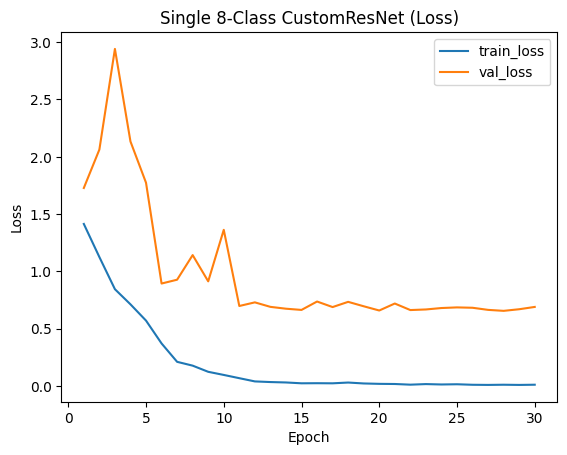

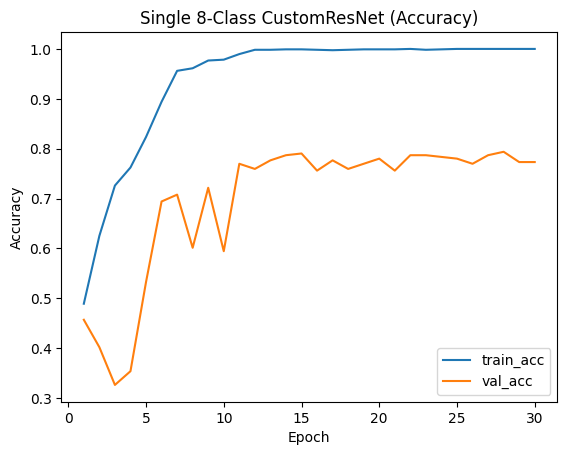

In [27]:
def plot_history(history, title="Training Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history["train_loss"], label="train_loss")
    plt.plot(epochs, history["val_loss"], label="val_loss")
    plt.title(title + " (Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(epochs, history["train_acc"], label="train_acc")
    plt.plot(epochs, history["val_acc"], label="val_acc")
    plt.title(title + " (Accuracy)")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

plot_history(history, title="Single 8-Class CustomResNet")

In [28]:
@torch.no_grad()
def collect_preds(model, loader):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        logits = model(x)
        pred = logits.argmax(1).cpu().numpy().tolist()
        y_true.extend(y.numpy().tolist())
        y_pred.extend(pred)
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = collect_preds(model, val_loader)

/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/JpegImagePlugin.py:887: UserWarning: Image appears to be a malformed MPO file, it will be interpreted as a base JPEG file
  warnings.warn(


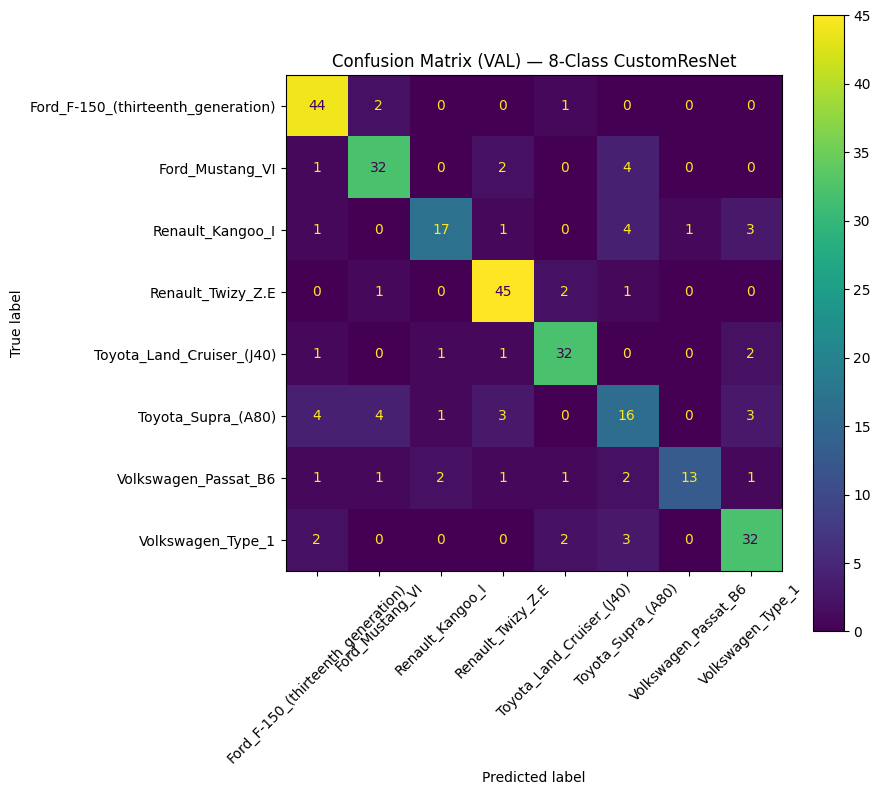

In [29]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix (VAL) — 8-Class CustomResNet")
plt.show()

In [30]:
from PIL import Image

@torch.no_grad()
def predict_image(img_path, model, class_names):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    x = val_transform(img).unsqueeze(0).to(device)
    logits = model(x)
    pred = int(logits.argmax(1).cpu().item())
    return class_names[pred]

test_img_path = "/content/Test/Ford F-150.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Ford Mustang.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Renault Kangoo.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Renault Twizy.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Toyota Land Cruiser.jpeg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Toyota_Supra.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Volkswagen Passat.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

test_img_path = "/content/Test/Volkswagen Type I.jpg"
print("Prediction:", predict_image(test_img_path, model, classes))

Prediction: Ford_F-150_(thirteenth_generation)
Prediction: Toyota_Supra_(A80)
Prediction: Renault_Kangoo_I
Prediction: Renault_Twizy_Z.E
Prediction: Toyota_Land_Cruiser_(J40)
Prediction: Toyota_Supra_(A80)
Prediction: Volkswagen_Passat_B6
Prediction: Volkswagen_Type_1
